# **Analisis variables - Adultos vs Kids**

# Bibliotecas

In [1]:
#Carga de datos
import pandas as pd
import numpy as np
import json
from Server_PD import download_dataframe_minio

from collections import Counter
import re

import seaborn as sns
import matplotlib.pyplot as plt
import isodate

import analisisutils as utils

# Carga de datos

In [4]:
# 1. Cargar claves
with open("Private/Claves.json", "r", encoding="utf-8") as archivo:
    claves = json.load(archivo)

claves["Url"] = claves["Url"].replace("https://", "").replace("http://", "").split("/")[0]

# 2. Lista completa de todos los archivos visibles en tus capturas (sin .parquet)
nombre_archivo = "union_dfs_20260303"

# Añadimos el prefijo de la carpeta grupo1 a todos
archivo_a_descargar = f"grupo1/clean/{nombre_archivo}"

#lista_df = []

print("Iniciando descarga masiva desde MinIO...")

#for nombre in archivos_a_descargar:
try:
    df = download_dataframe_minio(
        bucket="pd1", 
        object_name=archivo_a_descargar, 
        claves=claves, 
        file_format="parquet"
    )
    #lista_df.append(temp_df)
    print(f"Descargado: {nombre_archivo}")
except Exception as e:
    print(f"Error con {nombre_archivo}: {e}")

# 3. Concatenar y limpiar
if len(df):
    #df = pd.concat(lista_df, ignore_index=True)
    
    # Limpieza de duplicados por ID de video
    if 'video_id' in df.columns:
        antes = len(df)
        df = df.drop_duplicates(subset=['video_id'])
        despues = len(df)
        print(f"\nSe eliminaron {antes - despues} filas duplicadas.")
    
    print(f"\n¡Listo! Tienes un total de {len(df)} filas únicas para analizar.")
else:
    print("\nNo se pudo descargar ningún archivo. Verifica la conexión o los nombres.")

Iniciando descarga masiva desde MinIO...
Descargado: union_dfs_20260303

¡Listo! Tienes un total de 2548 filas únicas para analizar.


# Transformamos la columna "Duracion"

In [5]:

df['Duracion'] = df['Duracion'].apply(utils.iso_a_minutos)

# Dividimos los datos en "Adult" y "Kids"

In [6]:
# Kids
rangos_kids = ['0-4', '5-8', '9-12']
df_Kids = df[df["Rango_edad"].isin(rangos_kids)].copy()

# Adults
df_Adult = df[df["Rango_edad"] == "Adult"].copy()
df_Adult = df_Adult.head(len(df_Kids)).copy()


# Duración

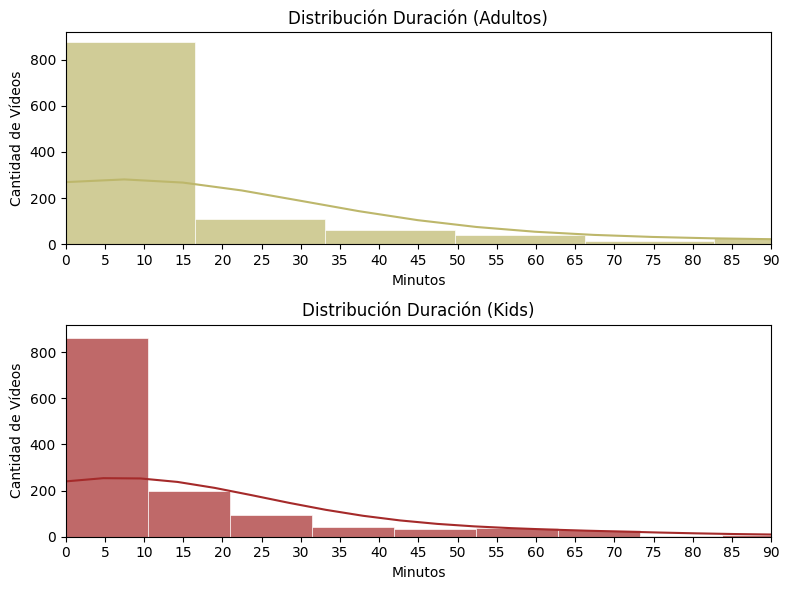

In [7]:

# Configuración
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharey=True)

utils.graficar_histograma_duracion(df_Adult, 'Distribución Duración (Adultos)', ax[0], 'darkkhaki')
utils.graficar_histograma_duracion(df_Kids, 'Distribución Duración (Kids)', ax[1], 'brown')

plt.tight_layout()
plt.show()

Kids: La distribución extremadamente concentrada en duraciones muy cortas (generalmente entre 0 y 10 minutos). Se puede observar que apenas hay videos de más de 15 minutos, lo que indica que el contenido infantil está diseñado para captar la atención de forma rápida y breve.

Adultos: Aunque también tiene un pico en duraciones cortas, hay más variedad. Desde vídeos cortos informativos (de entre 0-15 minutos) hasta contenidos más extensos que el público adulto es capaz de retener.

C:\Users\Marina\AppData\Local\Temp\ipykernel_35284\4239985363.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grupo', y='Duracion', data=df_total, palette='Set2')


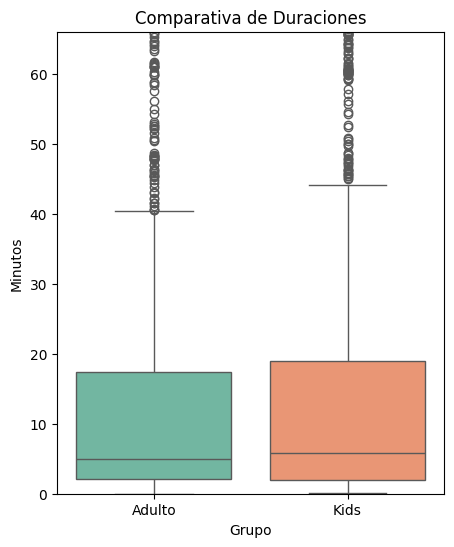

In [8]:
df_total = pd.concat([
    df_Adult.assign(Grupo='Adulto'),
    df_Kids.assign(Grupo='Kids')
])

plt.figure(figsize=(5, 6))
sns.boxplot(x='Grupo', y='Duracion', data=df_total, palette='Set2')     

# zoom para que se vea mejor
limite_superior = df_total['Duracion'].quantile(0.95) * 0.7 
plt.ylim(0, limite_superior) 

plt.title('Comparativa de Duraciones')
plt.ylabel('Minutos')
plt.show()

Como se puede observar la mediana es prácticamente igual para adultos que para niños. Esto sugiere que hay un tiempo ideal para mantener la atención antes de que el usuario pase al siguiente vídeo, independientemente de su edad. Se puede estimar que este valor está entre 5 y 8 minutos.

En ambos grupos vemos puntos por encima de los bigotes (outliers). En adultos estos valores extremos suelen llegar a duraciones mucho mayores, mientras que en niños, incluso los vídeos que se consideran más largos siguen teniendo una duración razonable.

# Top 10 géneros

c:\Users\Marina\Documents\Uni\ProyectoDatos\c2526-R1\src\analisisutils.py:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.values, y=top_generos.index, palette=paleta, ax=ax_obj)
c:\Users\Marina\Documents\Uni\ProyectoDatos\c2526-R1\src\analisisutils.py:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.values, y=top_generos.index, palette=paleta, ax=ax_obj)


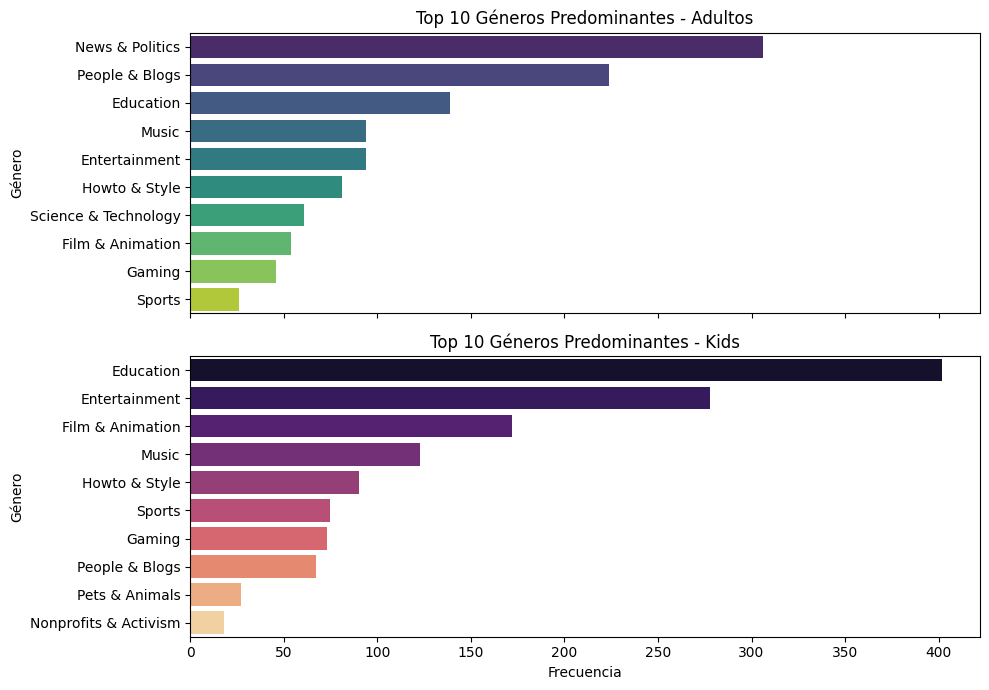

In [13]:
# Configuración
fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Llamamos a la función para cada grupo
utils.graficar_top_generos(df_Adult, 'Top 10 Géneros Predominantes - Adultos', ax[0], 'viridis')
utils.graficar_top_generos(df_Kids, 'Top 10 Géneros Predominantes - Kids', ax[1], 'magma')

plt.tight_layout()
plt.show()

El perfil del público adulto destaca por su fragmentación y heterogeneidad temática. Por un lado, tenemos contenidos informativos y de actualidad ('Society', 'Politics', 'Knowledge') y, por otro, un consumo más de ocio ('Music', 'Film'). 

En cuanto al público infantil, lso temas mas comunes son; 'Entertainment', 'Music', 'Film'. Se observa que los contenidos se inclinan más hacia temas lúdicos. Aunque tambien observamos cierto caracter educativo con generos como 'Knowledge'.

Observamos que los géneros más voluminosos (Music, Entertainment, Film) están presentes en ambos grupos. Esto genera una ambigüedad por lo que consideramos que la frecuencia de género no es suficiente para clasificar con seguridad.

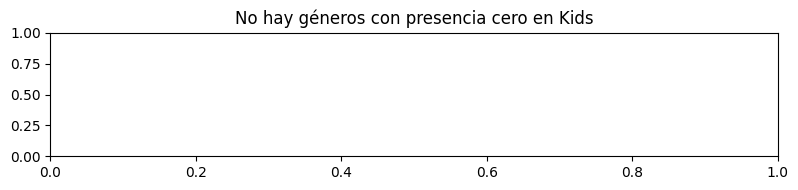

In [14]:
fig, ax = plt.subplots(figsize=(8,2))
utils.graficar_generos_ausentes_kids(df_Adult, df_Kids, ax)

plt.tight_layout()
plt.show()

La utilidad de los géneros en este modelo no reside en la frecuencia de los más usados, sino en la certeza de los ausentes, convirtiendo la escasez de datos en ciertas categorías en una herramienta de filtrado de alta precisión.

La ausencia total de estos temas en el grupo Kids nos permite establecer una lista de generos "prohibidos". Si el clasificador detecta una de estas etiquetas en un vídeo, lo mejor es que este sea descartado como apto para niños, independientemente de si su vocabulario o duración sugieren lo contrario.

Por lo que se ve en la gráfica los temas que no son aptos para niños tienen que ver principalente con la violencia.


# Densidad de habla (wpm)

In [15]:
#Agregamos una nueva columna a todos los df
df_Adult['Palabras_Por_Minuto'] = df_Adult.apply(utils.calcular_wpm, axis=1)
df_Adult['Palabras_Por_Minuto'] = round(df_Adult['Palabras_Por_Minuto'], 2)

df_Kids['Palabras_Por_Minuto'] = df_Kids.apply(utils.calcular_wpm, axis=1)
df_Kids['Palabras_Por_Minuto'] = round(df_Kids['Palabras_Por_Minuto'], 2)


C:\Users\Marina\AppData\Local\Temp\ipykernel_35284\3005112938.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grupo', y='Palabras_Por_Minuto', data=df_wpm_total, palette='Set2')


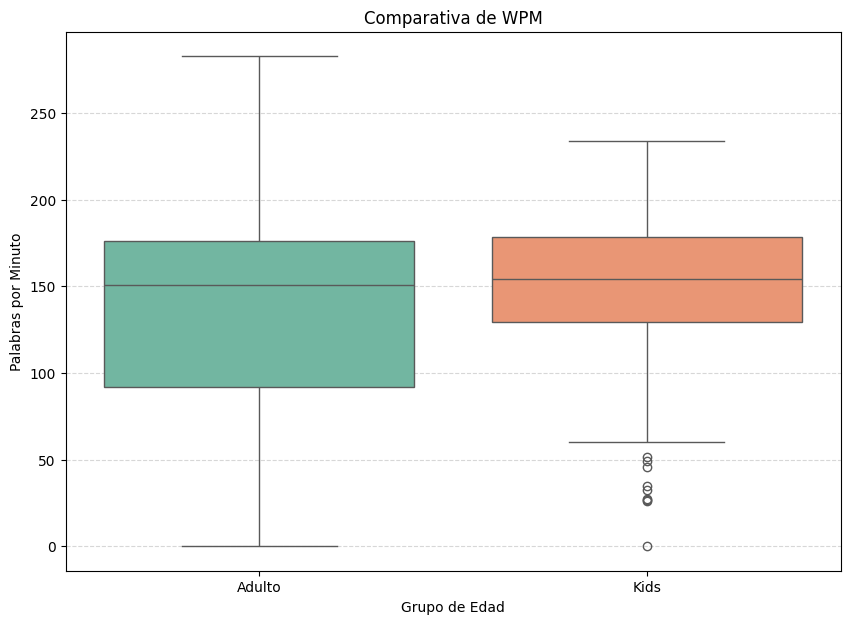

In [16]:
# Filtramos los vídeos sin palabras que no tienen subtitulos
df_wpm_total = pd.concat([
    df_Adult[df_Adult['Palabras_Por_Minuto'] > 0].assign(Grupo='Adulto'),
    df_Kids[df_Kids['Palabras_Por_Minuto'] > 0].assign(Grupo='Kids')
])

#Gráfica
plt.figure(figsize=(10, 7))

sns.boxplot(x='Grupo', y='Palabras_Por_Minuto', data=df_wpm_total, palette='Set2')

plt.title('Comparativa de WPM')
plt.xlabel('Grupo de Edad')
plt.ylabel('Palabras por Minuto')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Sorprendentemente, la mediana de palabras por minuto en el grupo Kids es ligeramente superior a la del grupo Adulto. Esto sugiere que, cuando un vídeo infantil es de carácter narrativo o educativo, mantiene un ritmo verbal constante y dinámico para mantener la atención del menor.

La caja del grupo infantil es notablemente más compacta. Esto indica que el contenido para niños sigue un estándar de producción muy rígido, el ritmo de habla es más uniforme.

El grupo Adulto presenta una caja mucho más amplia y bigotes más largos. Esto refleja la enorme heterogeneidad de su contenido; mientras que en Kids el ritmo es predecible, en adultos conviven géneros con una carga de guion mínima junto a otros de altísima densidad verbal.

Para nuestro clasificador, esto significa que el WPM por sí solo no define si un vídeo es para niños o adultos, sino su variabilidad.

Es importante señalar que la muestra de vídeos infantiles con subtítulos disponibles es considerablemente menor que la de adultos. Esto suguiere que los resultados de WPM en el grupo Kids podrían no ser plenamente representativos.

# Keywords 

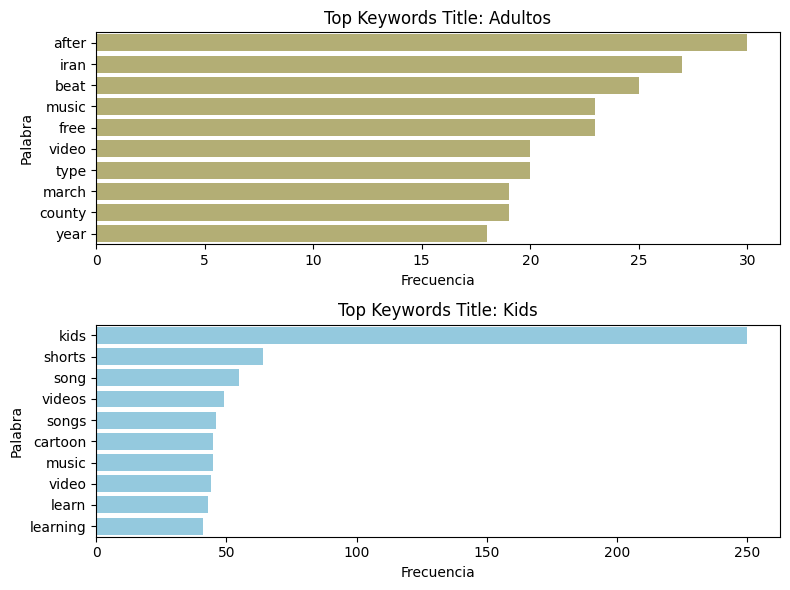

In [17]:
#Palabras más comunes en títulos
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

utils.graficar_palabras_comunes(df_Adult, 'Titulo', 'Top Keywords Title: Adultos', ax[0], 'darkkhaki')
utils.graficar_palabras_comunes(df_Kids, 'Titulo', 'Top Keywords Title: Kids', ax[1], 'skyblue')

plt.tight_layout()
plt.show()

Se puede observar que los titulos de los videos adultos tienen un enfoque más informativo. Las palabras clave como 'Trailer', 'News', 'Trump', 'Official' y 'War' confirman un consumo basado en la actualidad política y el cine. Los títulos son descriptivos y parece que buscan informar sobre un contenido específico.

Por otro lado los titulos de los videos infantiles aparentan ser mas genéricos. Los términos predominantes son 'Kids', 'cartoon', 'Song', 'nursery'. Esto refuerza la idea de un consumo lúdico donde se busca el entretenimiento directo.

En el grupo Kids, el uso de la palabra 'kids' es masivo. Esto indica que el modelo de predicción de éxito para niños debería dar mucho peso a esta palabra, ya que define el producto de forma casi inequívoca.

En el grupo Adulto, vemos palabras como 'new' y 'day', lo que sugiere que el usuario adulto valora la actualidad del contenido.


**SUBTITULOS**

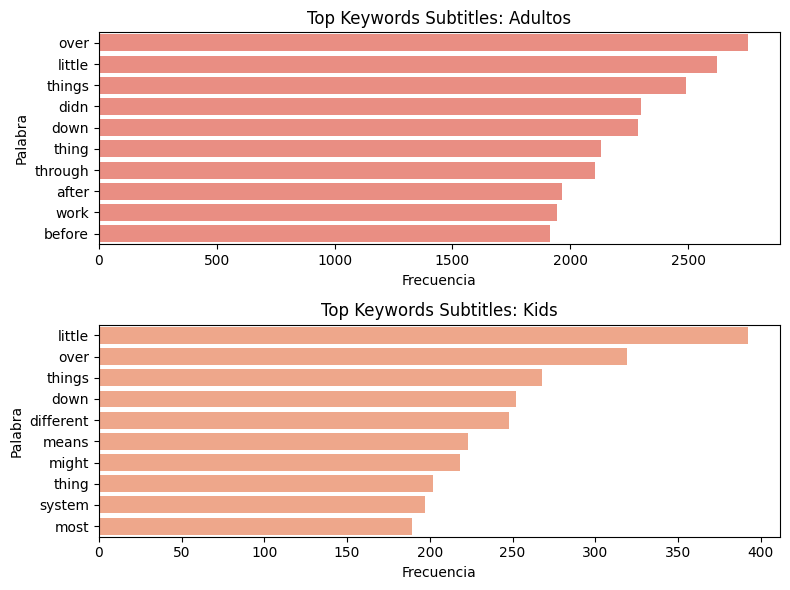

In [18]:
#Palabras mas comunes en subtítulos
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

utils.graficar_palabras_comunes(df_Adult, 'Subtitulos', 'Top Keywords Subtitles: Adultos', ax[0], 'salmon')
utils.graficar_palabras_comunes(df_Kids, 'Subtitulos', 'Top Keywords Subtitles: Kids', ax[1], 'lightsalmon')

plt.tight_layout()
plt.show()